# RUIE Benchmark Exploration (OPTIONAL ROBUSTNESS)
**Assigned to:** ___
**No GPU needed.**

Optional stress test dataset. Lowest priority. Include in paper only if time permits.

In [6]:
import os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    pass

candidates = []
if IN_COLAB:
    candidates += [
        "/content/drive/MyDrive/underwater_datasets/Realworld-Underwater-Image-Enhancement-RUIE-Benchmark-master",
        "/content/drive/MyDrive/underwater_datasets",
    ]
else:
    candidates += [
        r"d:\AISD_Project\turb-detr-underwater-detection\data",
        r"d:\AISD_Project\turb-detr-underwater-detection\datasets",
        os.getcwd(),
    ]


def find_ruie(paths):
    for p in paths:
        p = Path(p)
        if not p.exists():
            continue
        if p.is_dir() and ("ruie" in p.name.lower() or "realworld" in p.name.lower()):
            return str(p)
        for n in p.iterdir():
            if n.is_dir() and ("ruie" in n.name.lower() or "realworld" in n.name.lower()):
                return str(n)
    return None


DATASET = find_ruie(candidates)
if DATASET and os.path.exists(DATASET):
    print(f"OK DATASET: {DATASET}")
else:
    DATASET = None
    print("RUIE dataset not found. Update candidate paths before full analysis.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK DATASET: /content/drive/MyDrive/underwater_datasets/Realworld-Underwater-Image-Enhancement-RUIE-Benchmark-master


In [7]:
from pathlib import Path
from collections import Counter

if not DATASET:
    print("Skipping tree view: DATASET is not set.")
else:
    root = Path(DATASET)
    for dp, dn, fn in sorted(os.walk(root)):
        depth = str(dp).replace(str(root), "").count(os.sep)
        if depth > 3:
            continue
        indent = "  " * depth
        exts = Counter(Path(f).suffix.lower() for f in fn)
        print(f"{indent}{os.path.basename(dp)}/")
        for e, c in sorted(exts.items()):
            print(f"{indent}  {c:>6} {e}")

Realworld-Underwater-Image-Enhancement-RUIE-Benchmark-master/
       1 .rar
  UCCS/
    blue/
         100 .jpg
    blue-green/
         100 .jpg
    green/
         100 .jpg
  UIQS/
    A/
         726 .jpg
    B/
         726 .jpg
    C/
         726 .jpg
    D/
         726 .jpg
    E/
         726 .jpg
  UTTS/
    pic_A/
      Annotations/
             1 .jpg
            59 .xml
      JPEGImages/
            60 .jpg
    pic_B/
      Annotations/
            60 .xml
      JPEGImages/
            60 .jpg
    pic_C/
      Annotations/
            60 .xml
      JPEGImages/
            60 .jpg
    pic_D/
      Annotations/
            60 .xml
      JPEGImages/
            60 .jpg
    pic_E/
      Annotations/
            60 .xml
      JPEGImages/
            60 .jpg


In [8]:
# === CHECK FOR ANNOTATIONS ===
from pathlib import Path

if not DATASET:
    print("Skipping annotation check: DATASET is not set.")
else:
    root = Path(DATASET)
    txt_n = len(list(root.rglob("*.txt")))
    xml_n = len(list(root.rglob("*.xml")))
    json_n = len(list(root.rglob("*.json")))
    print(f".txt: {txt_n} | .xml: {xml_n} | .json: {json_n}")

    readmes = sorted(list(root.rglob("README*")) + list(root.rglob("readme*")))
    if readmes:
        print(f"\nREADME: {readmes[0]}")
        try:
            print(readmes[0].read_text(encoding="utf-8", errors="ignore")[:2000])
        except Exception as e:
            print(f"Could not read README: {e}")

.txt: 0 | .xml: 299 | .json: 0


Saved: /content/ruie_samples.png


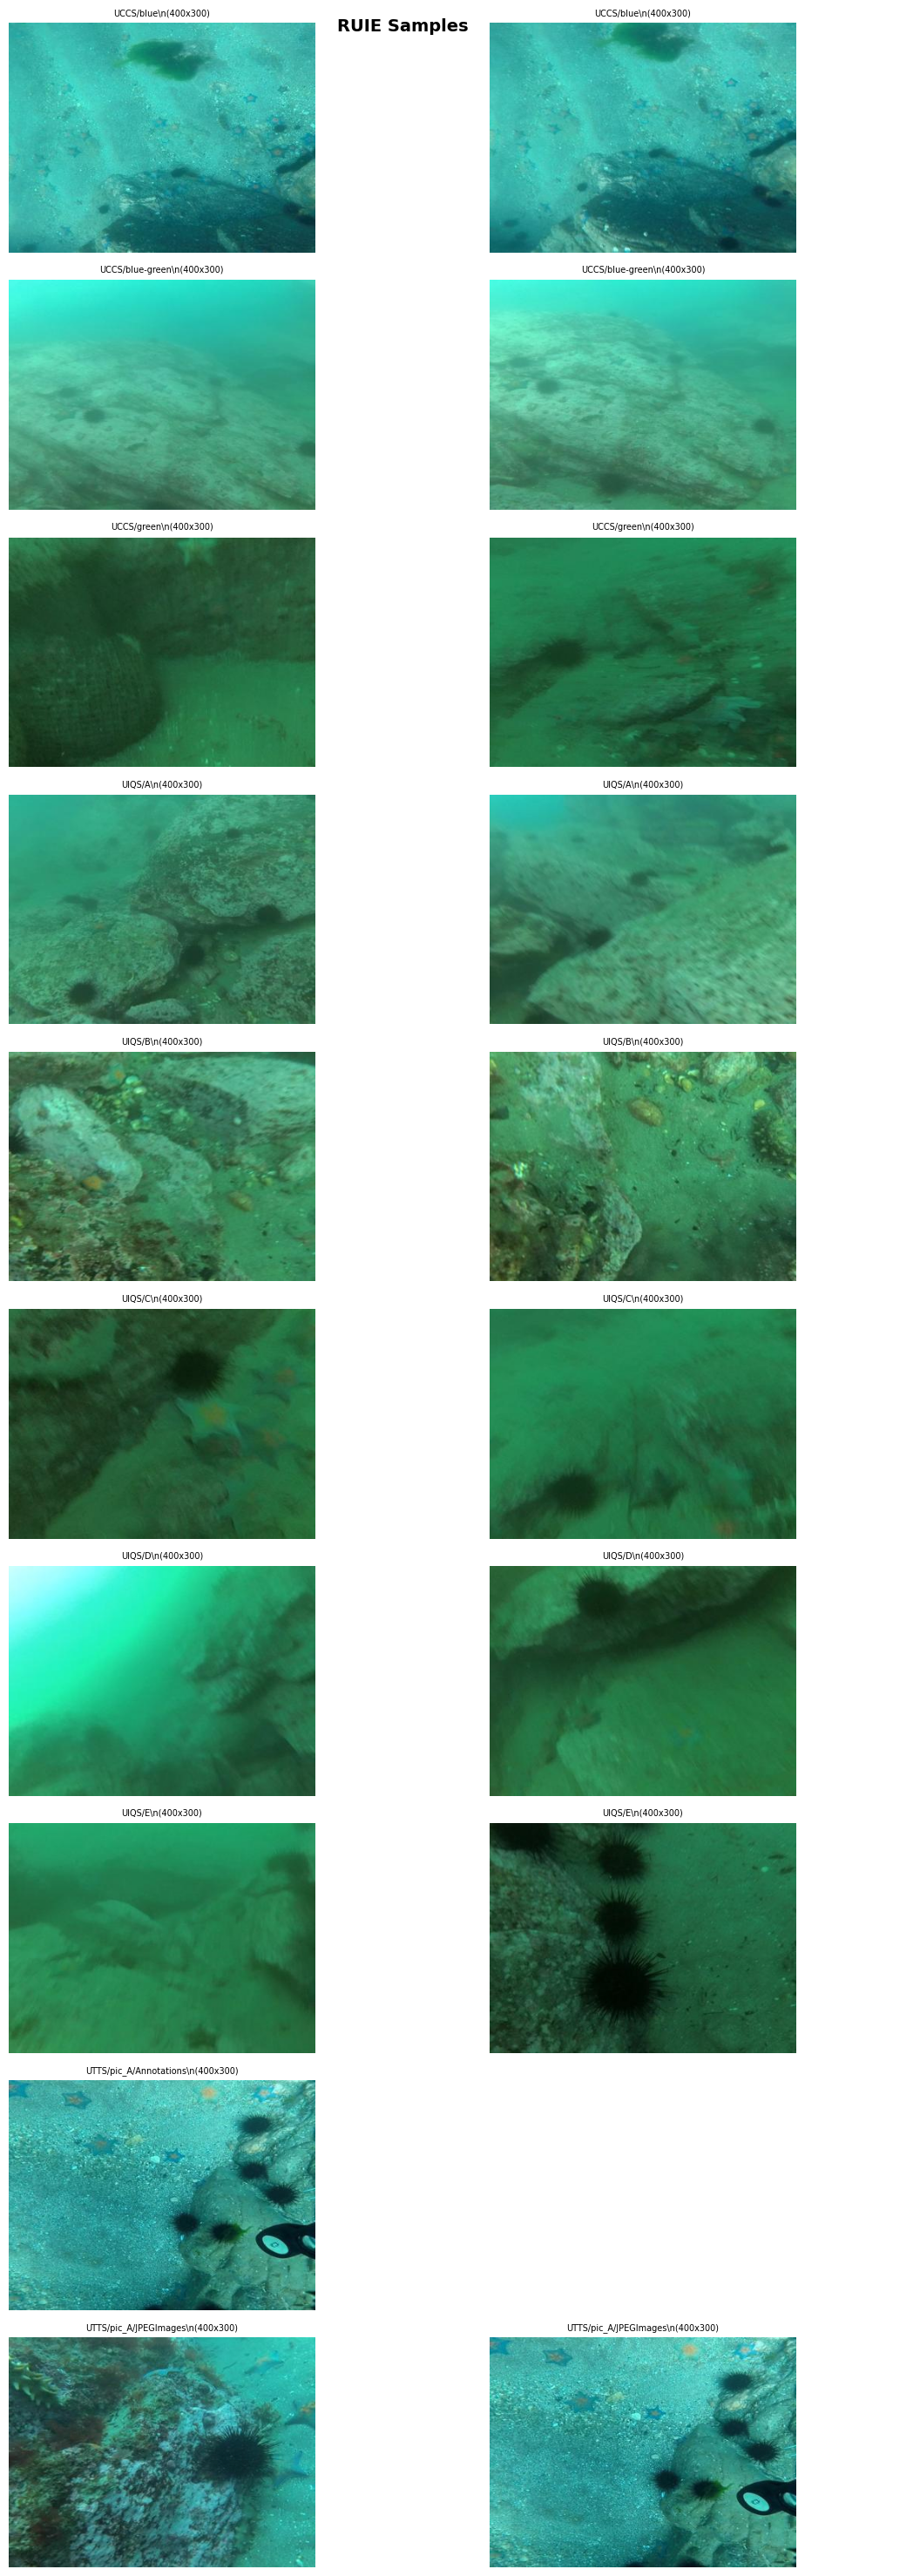

In [9]:
# === SAMPLE IMAGES ===
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

if not DATASET:
    print("Skipping sample preview: DATASET is not set.")
else:
    root = Path(DATASET)
    fi = defaultdict(list)

    for img in root.rglob("*"):
        if img.suffix.lower() in {".jpg", ".png", ".bmp", ".jpeg"}:
            r = str(img.parent.relative_to(root))
            if len(fi[r]) < 2:
                fi[r].append(img)

    flist = sorted(fi.keys())[:10]
    n = len(flist)

    if n == 0:
        print("No images found.")
    else:
        fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
        if n == 1:
            axes = axes.reshape(1, -1)

        for r, f in enumerate(flist):
            for c in range(2):
                ax = axes[r][c]
                if c < len(fi[f]):
                    im = cv2.imread(str(fi[f][c]))
                    if im is not None:
                        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
                        ax.set_title(f"{f}\\n({im.shape[1]}x{im.shape[0]})", fontsize=7)
                ax.axis("off")

        plt.suptitle("RUIE Samples", fontsize=14, fontweight="bold")
        plt.tight_layout()
        out_png = Path.cwd() / "ruie_samples.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_png}")
        plt.show()

In [10]:
from pathlib import Path

if not DATASET:
    print('''
================================================================
RUIE SUMMARY
================================================================
1. Total images: N/A (dataset not found)
2. Subsets: N/A
3. Has detection annotations: N/A
4. Has quality categories: N/A
5. Include in paper? MAYBE (after dataset is added)
================================================================
''')
else:
    root = Path(DATASET)
    img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    images = [p for p in root.rglob("*") if p.suffix.lower() in img_exts]

    subsets = sorted({
        str(p.parent.relative_to(root)).split(os.sep)[0]
        for p in images
        if p.parent != root
    })

    txt_n = len(list(root.rglob("*.txt")))
    xml_n = len(list(root.rglob("*.xml")))
    json_n = len(list(root.rglob("*.json")))

    has_det = "YES" if (xml_n + txt_n + json_n) > 0 else "NO"
    has_quality = "MAYBE" if any(k in " ".join(subsets).lower() for k in ["uiqs", "uqm", "quality"]) else "UNKNOWN"

    print(f'''
================================================================
RUIE SUMMARY
================================================================
1. Total images: {len(images)}
2. Subsets: {", ".join(subsets) if subsets else "N/A"}
3. Has detection annotations: {has_det}
4. Has quality categories: {has_quality}
5. Include in paper? YES / NO / MAYBE
================================================================
''')


RUIE SUMMARY
1. Total images: 4231
2. Subsets: UCCS, UIQS, UTTS
3. Has detection annotations: YES
4. Has quality categories: MAYBE
5. Include in paper? YES / NO / MAYBE



In [11]:
# === EXPORT SUMMARY FOR PAPER TABLES ===
import csv
import json
import os
from datetime import datetime, timezone
from pathlib import Path


def find_results_tables_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]

    if "DATASET" in globals() and DATASET:
        ds = Path(DATASET)
        candidates.extend([ds, *ds.parents])

    for base in candidates:
        target = base / "results" / "tables"
        if target.exists():
            return target

    return Path.cwd() / "results" / "tables"


out_dir = find_results_tables_dir()
out_dir.mkdir(parents=True, exist_ok=True)

if not DATASET:
    summary = {
        "dataset": "RUIE",
        "dataset_path": "N/A",
        "total_images": "N/A",
        "subsets": "N/A",
        "has_detection_annotations": "N/A",
        "has_quality_categories": "N/A",
        "include_in_paper": "MAYBE",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    }
else:
    root = Path(DATASET)
    img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    images = [p for p in root.rglob("*") if p.suffix.lower() in img_exts]

    subsets = sorted({
        str(p.parent.relative_to(root)).split(os.sep)[0]
        for p in images
        if p.parent != root
    })

    txt_n = len(list(root.rglob("*.txt")))
    xml_n = len(list(root.rglob("*.xml")))
    json_n = len(list(root.rglob("*.json")))

    has_det = "YES" if (xml_n + txt_n + json_n) > 0 else "NO"
    has_quality = "MAYBE" if any(
        k in " ".join(subsets).lower() for k in ["uiqs", "uqm", "quality"]
    ) else "UNKNOWN"

    summary = {
        "dataset": "RUIE",
        "dataset_path": str(root),
        "total_images": len(images),
        "subsets": ", ".join(subsets) if subsets else "N/A",
        "has_detection_annotations": has_det,
        "has_quality_categories": has_quality,
        "include_in_paper": "YES / NO / MAYBE",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    }

csv_path = out_dir / "ruie_summary.csv"
json_path = out_dir / "ruie_summary.json"

with csv_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    writer.writeheader()
    writer.writerow(summary)

json_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Saved CSV: {csv_path}")
print(f"Saved JSON: {json_path}")
print("Exported summary:")
print(json.dumps(summary, indent=2))

Saved CSV: /content/results/tables/ruie_summary.csv
Saved JSON: /content/results/tables/ruie_summary.json
Exported summary:
{
  "dataset": "RUIE",
  "dataset_path": "/content/drive/MyDrive/underwater_datasets/Realworld-Underwater-Image-Enhancement-RUIE-Benchmark-master",
  "total_images": 4231,
  "subsets": "UCCS, UIQS, UTTS",
  "has_detection_annotations": "YES",
  "has_quality_categories": "MAYBE",
  "include_in_paper": "YES / NO / MAYBE",
  "generated_at_utc": "2026-04-12T15:28:21.749915+00:00"
}
